# MCDI504 – Machine Learning I
## Evaluación Formativa 3 – Avance del Proyecto, Fase 3
### Implementación y evaluación preliminar de modelos de clasificación supervisada

**Caso:** Titanic – predicción de supervivencia de pasajeros  
**Variable objetivo:** `survived` (`0` = no sobrevivió; `1` = sobrevivió)  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** David Ruete Zúñiga  
**Grupo:** 2  
**Fecha:** 23 de agosto de 2026  
**Repositorio:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2

Este notebook se construyó para cubrir explícitamente los criterios de la **Formativa 3**: descripción y preparación del conjunto de datos, análisis exploratorio inicial, implementación de **KNN, Árbol de Decisión, SVM y Naïve Bayes**, evaluación mediante matrices de confusión y métricas, comparación preliminar, interpretación, trazabilidad y referencias. El flujo conserva la lógica y los parámetros del cuaderno docente entregado para la semana 3, ampliando la documentación y la evidencia analítica requerida por la rúbrica (Universidad Andrés Bello, 2026a, 2026b).


## 0. Reproducibilidad del entorno

El notebook está preparado para ejecutarse de forma secuencial mediante **Restart Kernel → Run All**. Se requiere Python 3 y las librerías `pandas`, `numpy`, `matplotlib`, `seaborn` y `scikit-learn`, incluidas en el archivo `requirements.txt` del repositorio.

La estructura relevante para esta fase es:

```text
MCDI504_MACHINE_LEARNING_1_GRUPO_2/
├── docs/
│   └── MCDI504_S3_ENTREGABLE_GRUPO2.pdf
├── notebooks/
│   └── F3_Clasificacion.ipynb
├── .gitignore
├── README.md
└── requirements.txt
```

**Instalación local en macOS o Linux (desde la raíz del repositorio):**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

**Instalación local en Windows PowerShell (desde la raíz del repositorio):**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

Después de abrir Jupyter, se debe seleccionar el kernel **Python (MCDI504 ML1)** y ejecutar todas las celdas en orden.

**Google Colab:** no requiere crear `.venv`, instalar JupyterLab ni registrar un kernel local. Se debe seleccionar un entorno Python 3 y ejecutar al inicio:

```python
%pip install pandas numpy seaborn matplotlib scikit-learn
```

El dataset principal es Titanic de `seaborn`. Si la descarga no está disponible, el notebook utiliza automáticamente una copia comprimida del mismo CSV, con 891 observaciones y 15 columnas. Por ello, una vez instaladas las dependencias, la ejecución no depende de conexión a internet.

Para mantener resultados comparables se utiliza `random_state=42` en los modelos que admiten aleatoriedad. La partición entrenamiento/prueba conserva la configuración docente: **80 % / 20 %**, `random_state=42` y sin `stratify`. El `StandardScaler` se ajusta únicamente con los datos de entrenamiento para evitar fuga de información.

`.venv/` y `.ipynb_checkpoints/` son elementos locales y deben permanecer excluidos mediante `.gitignore`.

Las figuras se muestran dentro del notebook y también se guardan automáticamente en `figures/fase3_clasificacion/`.


In [1]:
# Librerías base para entorno, datos, respaldo y visualización
from pathlib import Path
import sys, io, gzip, base64
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sklearn

# Herramientas para preparar datos y entrenar los cuatro clasificadores
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
# Métricas para comparar desempeño y errores por clase
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Carpeta portable para guardar las figuras generadas
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures' / 'fase3_clasificacion'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Versiones utilizadas en la ejecución actual
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")


Python: 3.10.4
pandas: 2.3.3
NumPy: 2.2.6
seaborn: 0.13.2
matplotlib: 3.10.9
scikit-learn: 1.7.2


In [2]:
# Carga del dataset Titanic. Se intenta primero la fuente estándar de seaborn.
# Si no hay internet, se usa una copia embebida del mismo CSV para asegurar reproducibilidad.
_TITANIC_GZ_B64 = (
    "H4sIAKpZi2oC/71d2Y7dxhF9z7dcEKxe2OSjZ6zxs6C8B7I0iYTIkqElTv4+3Hov3q6qHhsGDCMZ8pLs7lpOnTr17cfX/3z8z/P72+/vPr399u327fm/t7f/"
    "er59+/jrt99vv7/9+u7D7Z9vvz7fnn/79e3Xf69/ePzdHx++3N6+//Hp+z9+e/vp+fb++d2/zz/5x/cvf3y+vf203nX995fPz38bb/q2/5VSw3iD23hzg7K3"
    "N7e/f/j49f36f32+/f3rj+fb7c2XH98/vP3t9+9fPt8+f7k9vf307flvsF7xz+f9ej3762FQs9a3x9vTx6/fvt/++LLdZP/79X97/PD89dcvP77+6/a/52/h"
    "LtrfRU3rXcb9KZbkMdJ7ZE+y3WR7vuxJ7PkkVg+w3gJ7jPIex4OEj7HfYvtnfSnCx9ifIFx8XmjsrG+vq0tf/3h+/vxtX4d4JRxXWnP+rIVhnvb3Px4+XP7q"
    "/k9va6jXuykYRhcf/N2Hj5/eY58vWci4BG5/CHUDGECvC0laBH8b5W8D5lwFPa7PMs7bR39+9+Vz8TSN/XDcZP1nGhz6Or9cPknYD3Y+v+q6uawlbojiu44d"
    "+0Ev+0vYm15PhiOfrTF+BTDhVMzWKNK6nqcirIf1Wxq2I/bGL0b7ZGWby2ybaxlg3ZuvsYfId3fcFPFggE5/Hv8G2W/7Uw3nfoJ5v0FjT2I7+/yEan34R+z6"
    "fC+eD6AKi6Cm9vOnn/+42i/gxdv/fGXU4hZILJJaVPPrZ4bxWD5/DNZXQSzLT80VmF/AuJxeYj8LenaWY1xyA5uvY1yHuIiVeYVlfwO1ruGxDMUneKTuoNkl"
    "K5A9ObYC5XPPi53JNuR8dOMN0GqdndqtafHwyIsnNvA4OWY1gOnF6aM/tEzx+fTOct783P+Td+sw7nuPdHrGbOduLzCrAVz75f128d/ORzZWYat+vej5ZluX"
    "/N5uQ+wlyJyGP/HbW6sugxd88OrKlQEXXqDpgpPn2LfedpNlMJQDmyyAymKK7R77N2k7n8wJVmeHcugTz6f331Y3A4N1+yoKApHddvSfflE8ua/gZrRb0eTL"
    "nFn/s+pYr8k1dj4asfgjC+v3Yu2Z89fdGWyswdM0s7xNff7SR2g57GAxzeLzmTX0PA5/bTR/vtg2ceP7uyh61FWYr+nw/HCbYFhc8iDhVR6wxQh+/47Pf7wK"
    "O+LzA2q4OVHjvF5ItKFY2HoeXrXv4jfo0W2EC7C9g90MwDQsoo2kwkZivEKeGe+Hf7OkqOtNv5v3Wj6LnfVpd2nRSnhq44Mdx3zrdN/wwo1osGAzWMo0jPX1"
    "kbm/5Z4aey4Y63mALQunHv5ovg7zozgwRLlpptN9z8M0KUbW51MGJQqZ4itM2K6nee3CfGreA8TXP4LOwWw5K8mDhC0U3t5Og2nHy4jZseHMTsjHfyJAOMxI"
    "XejmQ444DutO3b7+fgA4li7Nr3yeAIoWrSFfzn/6JQk72ycnP7vLYKlLhoQrMy9gKRNc4xLcr/310zMvcXXp59e70d3DtVlmN+A4OHrDDDQPLRLuv+ColEbz"
    "YxZyqkwHUqaWnotHHCSjZtjeYK1hFjgK9IoZ/D1UWfePYOFszDCU/bOtTnht5638ut2mw05XwBAe3cQtswenetCbq60ub4bIJzYGx714IXIKrwEdnKvSlWA6"
    "Cpt/z12+GLZzOlq4uXXlZ2zr/dzYOlqHczNxtr6/3J2hSh7tUDfu1ccjR1tJojbxaj75x3fOsuME3fvwx74za6BJclklNuWdDo5NPTajPLP6KizMusA27iQ3"
    "MpRKRXRoVpaZ6Vee1xxVswY6X5t+QKuGxO3vxpChOkut2Klbkd8Dy/JA5i1X27duBIsmWg8NpEWdmUpRXKIkemmgr+iBfmfAkWY4Fq8QNnKE6DrUuXJw6Tpe"
    "XZ3/vOTKN77B+IDqAVkvYLq7uw+qYGsNeLdfFkTcmydfTYC+OnZP95/c+DRrTTIdvzKqc+NLq+bU8Z7EcBkXE1TLgtdfBNxTRZpKKYvW1sd/v606eIAt909Q"
    "GfGfQMkW8R+kjTcoyNlAKLXDCBdkoAqmkDQqmBw7fAqHYL2+aT/LbXAwHQqs6trv1GyJiA06buzibxGqNPKkcQnHkO3CwEdAq/2y7C0Iy8nQ0FMG0FLLa8rF"
    "78fEec7Pt+zeS5X5MsMBro9u/SnADuFT43qjeg6xhQjZWGXp3ALI9uCeuk7DJEvbrT09qSTzNuP5/TJTyoof3KBBsZNXC7E0otHSSOP0QqSbuY3qxK+S6bGf"
    "KUbDh4tL5/V7T8tBaOJ9cONDnvXtgc70U1lB+PQ6TlgUSr47P2wI+YLs04G4tBisVnCb43lkG3dAeWn7Guy0LOzIvrpzZP1CHCUik5d4KKlXVuKxZ9JEwUvr"
    "pJ8G0FdHdwq4k8Yqkw8NiyOmosWj75mFBcuRU1kU5p3eevlDsNqQ6Qh/CdBb3Mbz+QZUvLO0uzuXyw5mosRccef4wmxgJM2Dg52KdZ/vW+d/o8ht6uC0j6tH"
    "cpkiDftq88kojYWY29Ii7jG1G2eyrrmmR0XrpQ7rdVElemqXiYy3X2vkwLNfue2wI4Za/UTCzDJGSxsyg6wwXtN5qYDfSWcCDqOm3nRMtDBFLMYGYnH1/KoI"
    "9TmnpiQyQV0mIbK7E0YVFPEybQ9Ggo25oDTeYyWWoW/gdrO4jSh0T0+cdBb2w8b1H+kGuJ9SmeaNjL107cOX4a+MPwMZmhk5RMjJMhnAkPlMYrSO5Zp+xWFc"
    "3eaF4fyl9foKTffJCXOg0s5HoZxESr3IeRgbDyoq8s7IvxuzIIG/4YN2qfkMth+kTQxKUmV9kYjltLqOzuOEuvlh/WXlLIuMWHb28JurcqQDDps9MsAeqPyf"
    "mwa17GB5+0WuFoFBjIIKbORZAFWgVaINYKEXK2CGHXDLW/OWsV1kxNKcyAjSbFoTLIzlQjuvrPi8RmiTuVzeP2MpEqVEUPciFixOHqdmEaElquCVgOadl4SB"
    "y8pZsDKH6SMznm9PzNYKmyUihyROZ05qJFwKsuQQ1G5HR4RYOdH3wygCjCqHJGHLa+SSxS8dNvCxPj0m1G1mu9i+cZQ3m69rs3mVKnp3a9Fj29y5UIX4AVmn"
    "VxihKM7BxjCxR8J3t8CNLKAV06uyDioJu8RXl8qAO/0CvzRQzkndBwweCVsIjsZZEDTvGohgsQJlZa1cykPOxFrlFeJclElb/a+pKwuVjmnAHdkDrTX/aHBX"
    "g77qqsEfRBXII0jK7p2EC93jCz3sqzxuuxx0NyrPtMy/0GDugehKCalf7YemHkO+R95Y3YWc+dqAXNGYfldKABv2p709ocdj2D6G9b8mfUGceGxwj2IWTSWr"
    "l80NbewbO0DGl01hYXqVnPIxHhUYV4MAj614QoY/nFdP2m+ENZE9+ns4rJW8fkbnblTnIVkC3lFw/eWrM7GA3avISCOTxYAgGvaZcn4FjOOE8mO5PSawiDL4"
    "rOQ50csWKMl64gKPwXkyGmOwEJhZdeDTU1CCkhIjhpWsz3xgnojTb8UOoXCxbPoTF6HDwwVdsfJgajiw01qJ4y5dLGlvma2gTSDBPyWtAuyezPjDmt+Gm1R7"
    "1dnbAhbSGDq1WI/XYEji7UZWHzLUMV9JlP6zNSwg74fXg2rYynv0vJHRUqeyh97i5e2HUYrzi+oOhAUbh0XxFv066YA1ZJyvVMEaiQcEpu44DwtDVyyHjM8+"
    "jZFMM68zHzutn+TC8rxqvEW0HPpoSqa8R/Up5pPsqNakVl/UAa5tYGqNgZ5AvVTLT4TkkgKy4pFGa504ehUbRVf6+NtBsW2XWuFTN7UHB2Ayw3zAzKKMJNIa"
    "9AYVUXboHZUDfvOl6yVGJI3LV4buwj6rggcLRQc1Cxhgl7XTxZzKrJB8xmNQDqE4rrSTlEinJiugrTamIWYXlpdepNZqOp22dblyCc9n136X02Dn2QK7DgkZ"
    "+4OsOxABDHjdDZWME31THZ5vTT4mYtx8RziJ21mxYLzytlwaFEDDyDBKecxlbE+uF67G1W/uZ03qJThOynR01KvC18pahLoajC6MCdkYEShKT224ahRy5qoC"
    "Vgrgk0yZzvluYClSOlibnOpirIc+r2WvYkmSRm15/cVRdPKgGGdJI7252GIyYNzCEblwJ+e1ld00Qmq+qjSfmNy8Xq3JF9OqPOPJoreAKl4UOyMDVkHJuWps"
    "FthV61rD2f0FmntowVmw+SafqTo7KCHNC4N52un2C2HzweKvQbTmUXpzi7GePmMAqS000pigPEhll15hNRI1FaWuMoCW4Uq0KoUau3nEWEqlEsrEGN7LpAnC"
    "LZcQV3tPKa08VDd2r1sJuLYfJFypNGQNZAHl9tSHDlhlrUVnqd7JBAEiTZLRWIRK4KsLH/ZnpA0l604kHCcUa+RlwI2Ci99AqdB2gyCAyIipFGuk4J3x6XfU"
    "VREK/EiwmjSlOZFy3ixRAyplxPrJyoH6lEr/X/N+7iNajtdokKNzdJSxRjongWw8ou/AojqrStZq3YsTW9MuDi+gWqI7jb5CdSHoUBfKtcNZ3RalwBGSutH3"
    "QFQnAwl9zgLGUqAOHvCZ6yyWz03tiROsoZBE/WJanNO67tRJLKkL1Slp/jWK3NznvXLpIVA06AvOXBrCZyeOQzrVfujKLq/EI52qrFK1m2+5qt/Yx96H0Ueh"
    "uzqbQPhZrk0EuK4EkVyTas1LrKbvDN9yZ8mRC63lJWX1z6L8lj5LVJRLd9+Cul1BCMhmiN6X03t1zXTIPTaJq/yCSKfKEiBhUbTU5+BR9j0/dowIwEKmx6Zl"
    "J4NG0Om5f2iTA09VvEpXiKcQdrQQ6NL/svT/jUfiWFNrohmFviDSWLxYzxJDH+WdxizaL7oIc0f9IPWnAIqhag23TGphhiMOwbbjTwSLplHOLlFxJu+7Zgkn"
    "FJ1g6ngEleoFEuaopNx3Ng8sL0ch0yDIbmm3jcuwMCVP8nDk+PEWqFXsAg+Iz8sAIyaz/EiQiGSxuJBgYiHMYyhkehpiG69aSNRhyYtxhhSedt3w0TGEhO3N"
    "/bLNnNdH1MFMB5gctIE1Sl141UAe5q5edfGww1lSdRET6kspJYppu2qtdooR7J1bc9z2lMgmdrXHFXNlOEXlNNHTuDnlBYwRpNKDO1r6Uc7RBeuprDksw6x5"
    "3RiZIJHiMPtfBqBRUVFnF2Fl66dHmHJnNvP1031ooLyEMZ+hsEhnJPX2wliBgGLy7lOkRtjZcScG5wFm2ViAasiiycILCgVkGg00opA3gsFZoT1ZD/cACy1c"
    "hbB3uugxsrisxloEyaZlBKTXwzPW8M6iUR0JJBLLgZR6+UTV59DP7eZBbZ+cXqApft9SOqKrXhKLN5Ncb3Zk0Y20tNOpIFqPrGB10pYsi0kR2DlYZcoxzR4m"
    "/j0JG7rjQN0Z7cxotYHmAUgtvMyRN+hQAoxYm8pIztTEapKNKMMyM0foKXqhrh6dhMr4wINX7W4sb0DsMhg6xQQ7vRLt2JgYrfc5IqbWzAa0xtE3ZPD4iNng"
    "FypHQE/dGKsW9oTWTU2L5p7+rrZUKbuzVo6U9BWM3LHOV2LnPDjhJaCMzOCt/sdtb84WM1lEisUpH0EdoslWIqXUJtWTZ79z1w0czmWmSsV7vVxNGFCE5gha"
    "SiRIvp/rkKIiyuc+kA0HjKvjYzDkqthVTs5We8TN6icqu7TUEb3TDF+1mIt86lKsT4P0JpANiaUqM2EpY9A2KtayRdVMa1PXigrNkZtLT6032Uv6wJfvsswR"
    "dFbjXW4EexaE4ZDRJ5yaDPgTXTVINwsDpSQlj2FWMBwYTEdsKDZfhTbl5jkRybgl69Vk+vrkZdMjQk3JTxdfPvfEOU2YOhN8QUWgKF0maZvmFNtrjEgDRqx9"
    "PXY1gKclWfuXFCfkzKg8a1Eh6Bc3FrDD5VwCzpTNAXwuHWOKPZJutPV+si6+/LCyVGDTlFOfH9/CYNLIl9onXyW/mpf89om2C9SHr1sbWKETkvKyaRCl2Sq4"
    "OcyxNVGMlDTq82oyPIscmeYgns+iRwHoVNrvu8ImDddtjch1l3t5tcWAeaC702POXeiAn34Haiffd8XqtEsmF3J0M9IuOSCM/LvXFtAxsktQGLcCUlxqAFU/"
    "aG+cTOIjTYGpgHfJQnNdGrI6SNZwfG8poqSlDUFmEQ0bkuJcOWWoVB26HLVwRT+EQq7/L5KPOIyT2iNTFh/DGEkxEopzdqQF9+JyJCOcYreIZLLJKAVl81QO"
    "L0a2PZtXaTMw2AMXbXef4UpCh2lmiaRWJapj/9oS3uCHqxJegEyxvDMr0laycUs9KnWw7mRlAYNR/xndThMmds3iPBvxgLKYHnYJDatksnMmHdDUe8sJ8GzB"
    "dMjozicjIusAvrJC15QGibpquJymWH41mHFT6KYX12JU63AlL2rjVXx5lrrv5YDRjtoUvXcn7J55jDa8yUSrnztp9hvpKx+dX8avbgbGiL8eyThugYbrg0co"
    "7NkWc/T7WubzJgm+ImEt828reXOOv5OMGcgbLFgWo1+3o5iNJtoE6ZkTcCm6mbg52xuO4VQOjbgb+ZUM4oN6IKwdLHeyWj0ih84f1ZGAyoPiO2ZTlZ2icDyG"
    "rL0oMulMOsuXHi0iZRASqpe/w9ZsLBmsEJBlomLGi3RIpxPZqnmo9MQ+pX8LiPuhTbjQirgS5C4bikavrpgrJLYroHUhgz8gKJTerGfhEXs06nGyhnN28jCT"
    "DoWWmIySbbs+acEixOKPfzdaBg9kHUmKybIu9QihynBY4zMA0+e55mAUX96NwpbOoiGUMw+gn+kfdYEkq67MybuS9QlA1ASct4yM5+X8yh+EgSnvkqDx/NMD"
    "D/X8I0avwdmMqhmepoaYyCFONY5RokTpd4Dp7DKZ8KPHslgoQNaUJYzPj40wYmhKpKMAd4U27jecJcz3tHzjlRU3cTatnWV1yENtwhxXpiobQr8plg8GJscJ"
    "2DtShrEaoiTw/NMo6jdURRe0iP0gQ8er8nUKbRBC3bwoAUS+Ur39TUzTJ+Tpn5q7N8iD3NHne7yf56UlAhYFvo74O/RJ0/GQm0diasRMIfajJfxl7LcIas+l"
    "KkS9hxltd0b1NyJEvc3rVqKWtsOZ+2RDFe/jtBhsUnaAERT/CR0sj/cBgwBY4GEkfbDwMpiZnDejdkwQDi59lkDPBKXOx8YsyTjQ+5KP/4oCfpCkgi/mifGU"
    "SsOj+1AyL2pzuPRhsA4VbC5tiOnRlrejSFseiiKP1Ttc2jQdV4CpuHl+3PHOsmmcKCtfOmMem0wVjctsTkVOhSoBBFbjcrAhVTjJ6SWCkJPOgzsms7Wk5nuz"
    "0j78qu/q2IFo+YU6XTCYtUSiqgyF6AlpL/TbhRoXs+RGSnEWoc1BNYqQMdUkKINJhnClXGJutSdyIEEmEAkJfLTT54CFPqUk1nr0KJ2LpUdxsQ9ueeMIbv1/"
    "bvF0gD35tCA4QFWvIHV9+CFPUbDDXKAITQemdYekmu6c1nVaHgFTJaCQ47Cm/CdTRapMO8tEAEqdcmI3Y7+0UykvK2u+F3bRxRQcREzUutLcbCNAKeS4vjm1"
    "/y6n0QtF/i10DZDOnFDaPEQd8oC2EFPUH2IBg9Z4ftU0Pg9aMobIyE2OEQ6Mjp3T3Eytn4irCr0D3VGiTmFbK6UjIQv+1BAos5GMZajSUBdcKI56XlowQbFm"
    "ynlPyzcatzp3sOLLMbIZYE2zO1DgJZTQEzu3attBhk8sVj2zjFKgu6dyVhSpGfyQuWPefRgKsn+99exzBc6gmMTQ7hnhnL+7vA6YhL25Hh6op5FS2GRFkjQd"
    "sp8cZSrb1d0ZsGUusuOtxhJ5FXvnA4MBCsj0jnmYUnSTQypkBDu4o8e6Vihr2AOxpakWiMWbY486iPW0wwEeB7OzdNa1sLJaX0Bqp2Fx/EEkWjbFAoodPXLk"
    "JTET6pxohEjniQrDLLJ8mdq3WTGqZ34IE+tNtAau4v2tsCEgwcrFch15zC5R8r3eOg/Npm+NQj2MreMtwNaBd1SoWJyHwLaaSIFLAeuOUlJw2fcIHJ2qK9NB"
    "wvoRyHC+d/qb7FqHoz2809dPPPHGk1unYpAsKqqZn4RX7T0mx4OhkJcO0wzp7rZw6M7B5/fZiwYiwlMHdGvWvYOXxFJXKbwnaB+CqCutBcCWZ4jMq6s5ePjt"
    "qd/XfG7JuGSxkG3AR9htCFktH5XffaTx6kTdKzCJ+KC1pNfuLNh6XtpTM9evpp0V6LLJ1zrhE1n+RqnzK3Krr6WPVbiSvylr9/QRi+goCYryhI5DSfriIWf6"
    "psIlmtEZ86Y1WrzWr92domFCuCrTkmRIkGHSgIELtmwNj6yxS1BN2YHJDPOhg02e2hrbIUA0r6Ieu6mrNiq6uqtcWhN8M8eaI4yz5o8dhzB5lKVPmWuCCZGH"
    "ftxGFTC7MOc3Siz0k/Oi4JTWO7YBVUogb3LYvenovSk5cY4baRnYbjz0wMMAaTsYq7Y4derrGq83WraRs2pMoUxoedlj3p+0kFVL0EF8hjjIuDaMOMW6Bdpj"
    "3QazEai8Ly/RBC5bfuud070w+LEp4BK4+nKhaN0rO5dKtwFxvsWV3J9Iz0FY/EgTkr3tJK8+MFocXR/6BmjZiFjrjxFfWTxi0LyCNdufgJmbJJ311ArI/wGF"
    "XbiVut4AAA=="
)

try:
    titanic_df = sns.load_dataset('titanic')
    fuente_dataset = "seaborn.load_dataset('titanic')"
except Exception:
    csv_bytes = gzip.decompress(base64.b64decode(_TITANIC_GZ_B64))
    titanic_df = pd.read_csv(io.BytesIO(csv_bytes))
    fuente_dataset = "copia embebida de seaborn-data/titanic.csv"

print('Fuente usada:', fuente_dataset)
print(f'Dimensiones: {titanic_df.shape[0]} filas x {titanic_df.shape[1]} columnas')
display(titanic_df.head())


Fuente usada: copia embebida de seaborn-data/titanic.csv
Dimensiones: 891 filas x 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Definición del problema de clasificación

El objetivo es **predecir la supervivencia de un pasajero del Titanic** a partir de información demográfica, socioeconómica y de viaje. La variable objetivo `survived` es una etiqueta binaria conocida para todas las observaciones, por lo que el problema corresponde a **aprendizaje supervisado de clasificación binaria**.

Se comparan cuatro clasificadores sobre la misma partición de datos: **KNN**, **Árbol de Decisión**, **SVM** y **Naïve Bayes**. Esto permite interpretar las diferencias de desempeño bajo una base experimental común. La comparación considera `Accuracy`, `Precision`, `Recall`, `F1-score` y matriz de confusión, evitando basar la conclusión únicamente en Accuracy (Universidad Andrés Bello, 2026a; Pedregosa et al., 2011).


## 2. Descripción del conjunto de datos

El dataset contiene 891 registros y 15 columnas. `survived` es la variable objetivo. Las columnas `class`, `who`, `adult_male`, `embark_town`, `alive` y `alone` duplican o derivan información disponible en otras variables, mientras que `deck` presenta una proporción elevada de valores faltantes. El análisis siguiente documenta estas condiciones antes de preparar el modelamiento.


In [3]:
# Resume las dimensiones y el tipo de problema analizado
resumen_dataset = pd.DataFrame({
    'Elemento': ['Observaciones', 'Columnas', 'Variable objetivo', 'Clases', 'Tipo de problema'],
    'Valor': [
        titanic_df.shape[0], titanic_df.shape[1], 'survived',
        '0 = no sobrevivió; 1 = sobrevivió', 'Clasificación supervisada binaria'
    ]
})
display(resumen_dataset)

# Verifica el tipo asignado a cada columna original
print('Tipos de datos:')
display(titanic_df.dtypes.to_frame('dtype'))


,Elemento,Valor
0,Observaciones,891
1,Columnas,15
2,Variable objetivo,survived
3,Clases,0 = no sobrevivió; 1 = sobrevivió
4,Tipo de problema,Clasificación supervisada binaria


Tipos de datos:


,dtype
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


## 3. Análisis exploratorio inicial

El EDA se concentra en tres elementos directamente vinculados con la preparación para clasificación: **distribución de clases**, **calidad de datos** y **patrones preliminares en variables relevantes**. El objetivo no es demostrar causalidad, sino obtener evidencia que justifique decisiones de preprocesamiento y ayude a interpretar los modelos.


### 3.1 Distribución de la variable objetivo


,Frecuencia,Porcentaje (%)
survived,,
No sobrevivió (0),549,61.62
Sobrevivió (1),342,38.38


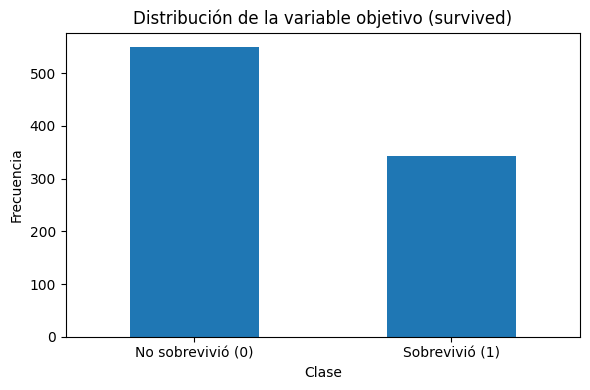

In [4]:
# Calcula frecuencia y porcentaje de cada clase objetivo
class_counts = titanic_df['survived'].value_counts().sort_index()
class_pct = (class_counts / len(titanic_df) * 100).round(2)
tabla_clases = pd.DataFrame({
    'Frecuencia': class_counts,
    'Porcentaje (%)': class_pct
}).rename(index={
    0: 'No sobrevivió (0)',
    1: 'Sobrevivió (1)'
})
display(tabla_clases)

# Visualiza el balance entre sobrevivientes y no sobrevivientes
ax = tabla_clases['Frecuencia'].plot(kind='bar', figsize=(6,4), legend=False)
ax.set_title('Distribución de la variable objetivo (survived)')
ax.set_xlabel('Clase')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '01_distribucion_clases.png', dpi=180, bbox_inches='tight')
plt.show()


La clase mayoritaria es **no sobrevivió** (549 casos; 61,62%) y la clase positiva representa 342 casos (38,38%). El desbalance es moderado: un clasificador trivial que predijera siempre la clase 0 alcanzaría cerca de 61,6% de Accuracy. Por esto, la evaluación debe incorporar Precision, Recall y F1-score además de Accuracy.


### 3.2 Calidad de datos y valores faltantes


,Faltantes,Porcentaje (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


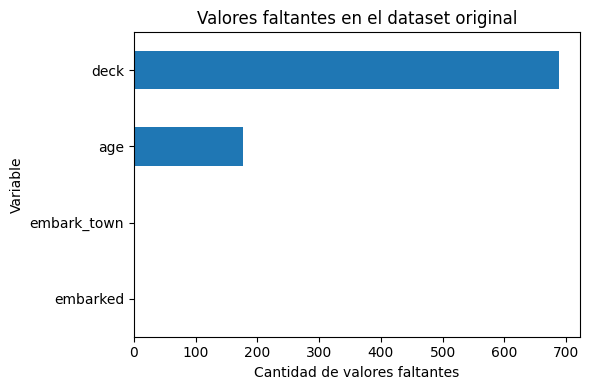

In [5]:
# Identifica las columnas que requieren tratamiento de valores faltantes
faltantes = titanic_df.isna().sum().sort_values(ascending=False)
faltantes_relevantes = faltantes[faltantes > 0]
tabla_faltantes = pd.DataFrame({
    'Faltantes': faltantes_relevantes,
    'Porcentaje (%)': (faltantes_relevantes / len(titanic_df) * 100).round(2)
})
display(tabla_faltantes)

# Compara visualmente la cantidad de faltantes por variable
ax = tabla_faltantes['Faltantes'].sort_values().plot(kind='barh', figsize=(6,4), legend=False)
ax.set_title('Valores faltantes en el dataset original')
ax.set_xlabel('Cantidad de valores faltantes')
ax.set_ylabel('Variable')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '02_valores_faltantes.png', dpi=180, bbox_inches='tight')
plt.show()


`deck` concentra 688 faltantes (aprox. 77%), por lo que se elimina en vez de imputarla. `age` presenta 177 faltantes y se imputa con la mediana; `embarked` presenta solo 2 y se imputa con la moda. Estas decisiones reducen pérdida de registros y evitan una imputación excesiva en `deck`.


### 3.3 Exploración de variables relevantes


In [6]:
# Compara las tasas de supervivencia por sexo y clase de pasaje
tasa_sexo = (titanic_df.groupby('sex', observed=False)['survived'].mean()*100).round(2).rename('Supervivencia (%)')
tasa_clase = (titanic_df.groupby('pclass', observed=False)['survived'].mean()*100).round(2).rename('Supervivencia (%)')
print('Tasa de supervivencia por sexo:')
display(tasa_sexo.to_frame())
print('Tasa de supervivencia por clase de pasaje:')
display(tasa_clase.to_frame())

# Resume las variables numéricas según la clase observada
num_vars = ['age','fare','sibsp','parch']
resumen_por_clase = titanic_df.groupby('survived')[num_vars].agg(['mean','median']).round(2)
display(resumen_por_clase)


Tasa de supervivencia por sexo:


,Supervivencia (%)
sex,
female,74.20
male,18.89


Tasa de supervivencia por clase de pasaje:


,Supervivencia (%)
pclass,
1,62.96
2,47.28
3,24.24


age          fare        sibsp        parch       
           mean median   mean median  mean median  mean median
survived                                                      
0         30.63   28.0  22.12   10.5  0.55    0.0  0.33    0.0
1         28.34   28.0  48.40   26.0  0.47    0.0  0.46    0.0

Las tasas observadas difieren por sexo y clase de pasaje, y las variables numéricas muestran perfiles distintos entre las dos clases. Estas diferencias justifican conservar variables como `sex`, `pclass`, `age` y `fare` como predictores potencialmente informativos. Se trata de **asociaciones descriptivas**, no de evidencia causal; su utilidad predictiva se evalúa posteriormente mediante los modelos.


## 4. Preparación de datos para clasificación

La preparación replica el flujo docente: eliminar columnas redundantes o con demasiados faltantes, imputar `age` y `embarked`, aplicar *one-hot encoding* a variables categóricas, separar `X` e `y`, realizar la partición 80/20 y escalar únicamente para SVM. El `StandardScaler` se ajusta solo con `X_train` para evitar fuga de información hacia el conjunto de prueba (scikit-learn Developers, s. f.-e).


In [7]:
# Copia para preservar el dataset original
titanic_df_processed = titanic_df.copy()

# 1) Eliminación de columnas redundantes/derivadas o con exceso de faltantes
columns_to_drop = ['deck', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
titanic_df_processed = titanic_df_processed.drop(columns=columns_to_drop)

# 2) Imputación
age_median = titanic_df_processed['age'].median()
embarked_mode = titanic_df_processed['embarked'].mode()[0]
titanic_df_processed['age'] = titanic_df_processed['age'].fillna(age_median)
titanic_df_processed['embarked'] = titanic_df_processed['embarked'].fillna(embarked_mode)

# 3) Codificación categórica
titanic_df_processed = pd.get_dummies(
    titanic_df_processed,
    columns=['sex', 'embarked'],
    drop_first=True
)

print('Mediana age:', age_median)
print('Moda embarked:', embarked_mode)
print('Faltantes después del preprocesamiento:', int(titanic_df_processed.isna().sum().sum()))
print('Dimensiones finales:', titanic_df_processed.shape)
display(titanic_df_processed.head())


Mediana age: 28.0
Moda embarked: S
Faltantes después del preprocesamiento: 0
Dimensiones finales: (891, 9)


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [8]:
# 4) Definición de predictores y objetivo
X = titanic_df_processed.drop('survived', axis=1)
y = titanic_df_processed['survived']

# 5) Partición 80/20, igual al cuaderno docente
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 6) Escalamiento para SVM, ajustado solo con entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Predictores finales:', X.columns.tolist())
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)


Predictores finales: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']
X_train: (712, 8) | X_test: (179, 8)
y_train: (712,) | y_test: (179,)


### 4.1 Justificación consolidada de la preparación


In [9]:
# Relaciona cada decisión de preparación con su justificación
tabla_preparacion = pd.DataFrame([
    ['Eliminar deck', '688 faltantes (~77%); imputarla introduciría demasiada información artificial.'],
    ['Eliminar class, who, adult_male, embark_town, alive, alone', 'Son redundantes, derivables o duplican información usada por otros predictores/objetivo.'],
    ['Imputar age con mediana', 'Conserva observaciones y es robusta frente a valores extremos.'],
    ['Imputar embarked con moda', 'Solo faltan 2 registros y es una variable categórica.'],
    ['One-hot encoding', 'Convierte categorías nominales a variables binarias sin imponer orden artificial.'],
    ['Partición 80/20', 'Separa datos no vistos para una evaluación preliminar reproducible.'],
    ['StandardScaler para SVM', 'SVM es sensible a la escala; el scaler se ajusta únicamente con entrenamiento.'],
], columns=['Decisión', 'Justificación'])
display(tabla_preparacion)


,Decisión,Justificación
0,Eliminar deck,688 faltantes (~77%); imputarla introduciría d...
1,"Eliminar class, who, adult_male, embark_town, ...","Son redundantes, derivables o duplican informa..."
2,Imputar age con mediana,Conserva observaciones y es robusta frente a v...
3,Imputar embarked con moda,Solo faltan 2 registros y es una variable cate...
4,One-hot encoding,Convierte categorías nominales a variables bin...
5,Partición 80/20,Separa datos no vistos para una evaluación pre...
6,StandardScaler para SVM,SVM es sensible a la escala; el scaler se ajus...


## 5. Modelo KNN

KNN clasifica una observación según las clases de sus vecinos más cercanos. La configuración mantiene la propuesta docente: `n_neighbors=5`, distancia Minkowski con `p=2` (distancia euclidiana). KNN es sensible a la escala; sin embargo, para mantener comparabilidad con el cuaderno entregado, en esta Formativa se conserva su ejecución **sin escalamiento** y se documenta esta decisión como limitación metodológica (scikit-learn Developers, s. f.-a).


In [10]:
# Documenta los hiperparámetros usados por KNN
ficha_knn = pd.DataFrame({
    'Parámetro': ['n_neighbors', 'metric', 'p', 'Datos de entrada', 'Objetivo'],
    'Valor': [5, 'minkowski', 2, 'X_train / X_test (sin escalar)', 'survived']
})
display(ficha_knn)

# Entrena KNN y predice el conjunto de prueba
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)


,Parámetro,Valor
0,n_neighbors,5
1,metric,minkowski
2,p,2
3,Datos de entrada,X_train / X_test (sin escalar)
4,Objetivo,survived


## 6. Modelo de Árbol de Decisión

El Árbol de Decisión aprende reglas jerárquicas de partición. Se utiliza `criterion='gini'` y `max_depth=5`, lo que limita la complejidad del árbol y reduce el riesgo de sobreajuste respecto de un árbol sin restricción de profundidad (scikit-learn Developers, s. f.-b).


In [11]:
# Documenta la configuración del Árbol de Decisión
ficha_tree = pd.DataFrame({
    'Parámetro': ['criterion', 'max_depth', 'random_state', 'Datos de entrada', 'Objetivo'],
    'Valor': ['gini', 5, 42, 'X_train / X_test', 'survived']
})
display(ficha_tree)

# Entrena el árbol limitado a cinco niveles y genera predicciones
dtree_model = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
dtree_model.fit(X_train, y_train)
y_pred_dtree = dtree_model.predict(X_test)


,Parámetro,Valor
0,criterion,gini
1,max_depth,5
2,random_state,42
3,Datos de entrada,X_train / X_test
4,Objetivo,survived


## 7. Modelo SVM

SVM busca una frontera de decisión que maximiza el margen entre clases. Se utiliza kernel RBF, `C=1` y datos estandarizados con `StandardScaler`. El escalamiento es importante porque SVM depende de distancias y productos internos en el espacio de características (scikit-learn Developers, s. f.-c, s. f.-e).


In [12]:
# Documenta los hiperparámetros y el escalamiento de SVM
ficha_svm = pd.DataFrame({
    'Parámetro': ['kernel', 'C', 'random_state', 'Escalamiento', 'Objetivo'],
    'Valor': ['rbf', 1, 42, 'StandardScaler (fit solo en X_train)', 'survived']
})
display(ficha_svm)

# Entrena SVM y predice con los datos estandarizados
svm_model = SVC(kernel='rbf', C=1, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)


,Parámetro,Valor
0,kernel,rbf
1,C,1
2,random_state,42
3,Escalamiento,StandardScaler (fit solo en X_train)
4,Objetivo,survived


## 8. Modelo Naïve Bayes

`GaussianNB` es un clasificador probabilístico basado en el teorema de Bayes y en el supuesto de independencia condicional entre predictores dada la clase; además, modela cada predictor continuo mediante una distribución gaussiana por clase. Es una referencia eficiente y útil para contrastar con modelos geométricos y basados en reglas (scikit-learn Developers, s. f.-d).


In [13]:
# Documenta la variante y los supuestos de Naïve Bayes
ficha_nb = pd.DataFrame({
    'Parámetro / supuesto': ['Variante', 'priors', 'var_smoothing', 'Datos de entrada', 'Objetivo'],
    'Valor': ['GaussianNB', 'No especificado (estimado desde datos)', 'Valor por defecto', 'X_train / X_test', 'survived']
})
display(ficha_nb)

# Entrena GaussianNB y predice el conjunto de prueba
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


,Parámetro / supuesto,Valor
0,Variante,GaussianNB
1,priors,No especificado (estimado desde datos)
2,var_smoothing,Valor por defecto
3,Datos de entrada,X_train / X_test
4,Objetivo,survived


## 9. Evaluación preliminar y comparación de modelos

Para cada modelo se calculan Accuracy, Precision, Recall y F1-score de la clase positiva (`survived=1`) y los cuatro componentes de la matriz de confusión: TN, FP, FN y TP. Esta combinación permite comparar desempeño global y tipo de error, tal como exige la Formativa 3.


In [14]:
# Reúne las predicciones para evaluarlas con el mismo criterio
predicciones = {
    'KNN': y_pred_knn,
    'Árbol de Decisión': y_pred_dtree,
    'SVM': y_pred_svm,
    'Naïve Bayes': y_pred_nb,
}

filas = []
matrices = {}
# Calcula métricas y componentes de la matriz de confusión
for nombre, pred in predicciones.items():
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    matrices[nombre] = cm
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-score': f1_score(y_test, pred, zero_division=0),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    })

# Consolida los resultados en una tabla comparable
resultados = pd.DataFrame(filas).set_index('Modelo')
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
display(resultados.style.format({m:'{:.4f}' for m in metricas}))


,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
Modelo,,,,,,,,
KNN,0.7095,0.6964,0.5270,0.6000,88,17,35,39
Árbol de Decisión,0.7989,0.8276,0.6486,0.7273,95,10,26,48
SVM,0.8212,0.8387,0.7027,0.7647,95,10,22,52
Naïve Bayes,0.7709,0.7200,0.7297,0.7248,84,21,20,54


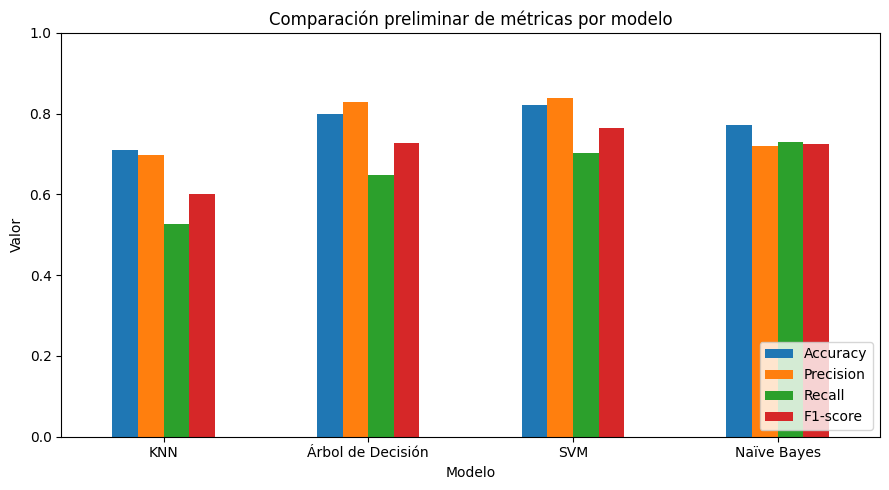

In [15]:
# Visualización comparativa de métricas
ax = resultados[metricas].plot(kind='bar', figsize=(9,5))
ax.set_title('Comparación preliminar de métricas por modelo')
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '03_comparacion_metricas.png', dpi=180, bbox_inches='tight')
plt.show()


### 9.1 Matrices de confusión


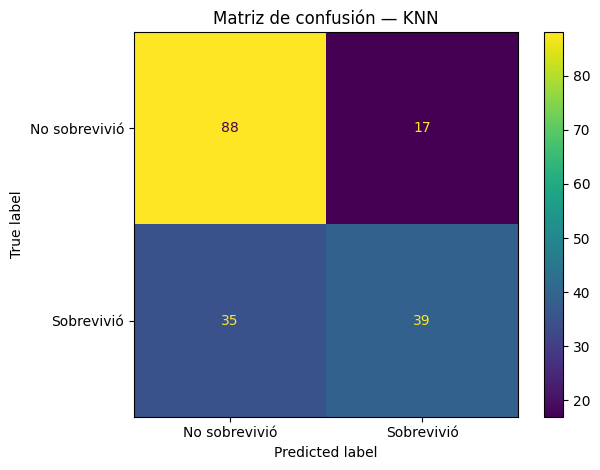

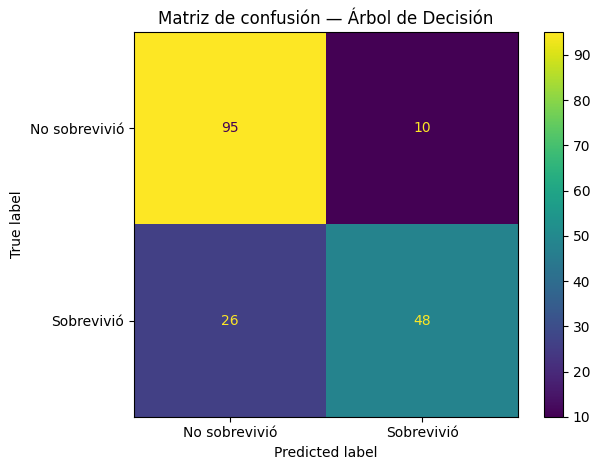

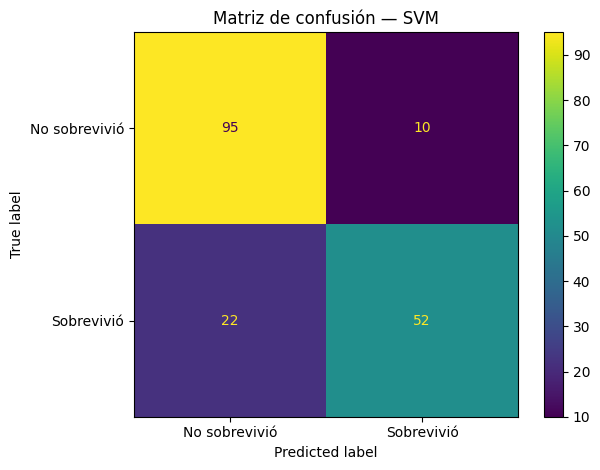

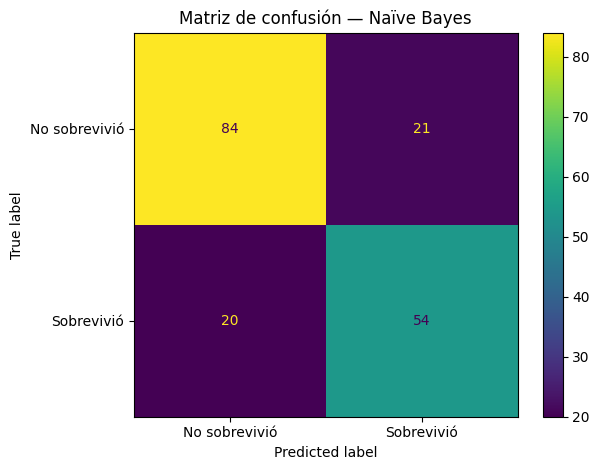

In [16]:
# Define un archivo estable para la matriz de cada clasificador
archivos_matrices = {
    'KNN': '04_matriz_confusion_knn.png',
    'Árbol de Decisión': '05_matriz_confusion_arbol.png',
    'SVM': '06_matriz_confusion_svm.png',
    'Naïve Bayes': '07_matriz_confusion_naive_bayes.png',
}

# Muestra y guarda los aciertos y errores de cada clasificador
for nombre, cm in matrices.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])
    disp.plot(values_format='d')
    plt.title(f'Matriz de confusión — {nombre}')
    plt.tight_layout()
    # Guarda cada matriz antes de mostrarla
    disp.figure_.savefig(FIG_DIR / archivos_matrices[nombre], dpi=180, bbox_inches='tight')
    plt.show()


### 9.2 Interpretación por modelo


In [17]:
# Imprime una síntesis numérica para interpretar cada modelo
for nombre in resultados.index:
    r = resultados.loc[nombre]
    print(f"{nombre}: Accuracy={r['Accuracy']:.4f}, Precision={r['Precision']:.4f}, "
          f"Recall={r['Recall']:.4f}, F1={r['F1-score']:.4f}, "
          f"FP={int(r['FP'])}, FN={int(r['FN'])}")


KNN: Accuracy=0.7095, Precision=0.6964, Recall=0.5270, F1=0.6000, FP=17, FN=35
Árbol de Decisión: Accuracy=0.7989, Precision=0.8276, Recall=0.6486, F1=0.7273, FP=10, FN=26
SVM: Accuracy=0.8212, Precision=0.8387, Recall=0.7027, F1=0.7647, FP=10, FN=22
Naïve Bayes: Accuracy=0.7709, Precision=0.7200, Recall=0.7297, F1=0.7248, FP=21, FN=20


**KNN.** Presenta el desempeño más bajo del conjunto: Accuracy ≈ 0,7095 y F1 ≈ 0,6000. Su Recall ≈ 0,5270 muestra dificultad para identificar sobrevivientes; registra 35 falsos negativos. Dado que se ejecuta sin escalamiento para mantener la configuración docente, esta sensibilidad a escala debe considerarse una limitación del pipeline actual.

**Árbol de Decisión.** Mejora claramente a KNN: Accuracy ≈ 0,7989, Precision ≈ 0,8276 y F1 ≈ 0,7273. Solo produce 10 falsos positivos, aunque mantiene 26 falsos negativos. Su fortaleza principal es la interpretabilidad; su desempeño puede depender de `max_depth` y otros hiperparámetros.

**SVM.** Obtiene el mejor equilibrio global en esta ejecución: Accuracy ≈ 0,8212, Precision ≈ 0,8387 y F1 ≈ 0,7647. Reduce los falsos negativos a 22 y mantiene 10 falsos positivos. La principal limitación es una menor interpretabilidad y la necesidad de escalamiento/ajuste de hiperparámetros.

**Naïve Bayes.** Obtiene Accuracy ≈ 0,7709 y el **Recall más alto** (≈ 0,7297), con solo 20 falsos negativos. A cambio, aumenta los falsos positivos a 21. Es una alternativa útil si el costo de omitir sobrevivientes fuera prioritario, aunque el supuesto de independencia condicional es restrictivo para variables potencialmente asociadas como `pclass` y `fare`.


### 9.3 Fortalezas y limitaciones


In [18]:
# Contrasta fortalezas, limitaciones y uso sugerido
fortalezas = pd.DataFrame([
    ['KNN', 'Simple y fácil de explicar por proximidad.', 'Sensible a escala; bajo Recall en esta configuración.', 'Línea base, no recomendado como mejor modelo actual.'],
    ['Árbol de Decisión', 'Interpretable; buena Precision.', 'Puede subajustar/sobreajustar según profundidad.', 'Alternativa interpretable con desempeño competitivo.'],
    ['SVM', 'Mejor Accuracy, Precision y F1 global.', 'Menor interpretabilidad; requiere escalamiento.', 'Mejor equilibrio global preliminar.'],
    ['Naïve Bayes', 'Mayor Recall; eficiente computacionalmente.', 'Supuesto de independencia condicional.', 'Útil si se prioriza reducir falsos negativos.'],
], columns=['Modelo','Fortaleza','Limitación','Lectura preliminar'])
display(fortalezas)


,Modelo,Fortaleza,Limitación,Lectura preliminar
0,KNN,Simple y fácil de explicar por proximidad.,Sensible a escala; bajo Recall en esta configu...,"Línea base, no recomendado como mejor modelo a..."
1,Árbol de Decisión,Interpretable; buena Precision.,Puede subajustar/sobreajustar según profundidad.,Alternativa interpretable con desempeño compet...
2,SVM,"Mejor Accuracy, Precision y F1 global.",Menor interpretabilidad; requiere escalamiento.,Mejor equilibrio global preliminar.
3,Naïve Bayes,Mayor Recall; eficiente computacionalmente.,Supuesto de independencia condicional.,Útil si se prioriza reducir falsos negativos.


## 10. Conclusiones 

1. Se construyó un pipeline reproducible de clasificación binaria sobre el dataset Titanic, incorporando limpieza, imputación, codificación categórica, definición de `X` e `y`, partición 80/20 y escalamiento específico para SVM.

2. Los cuatro modelos considerados fueron implementados sobre la misma partición de datos y evaluados mediante Accuracy, Precision, Recall, F1-score y matrices de confusión, permitiendo comparar su comportamiento bajo condiciones equivalentes.

3. **SVM** presentó el mejor equilibrio global en esta ejecución, con un Accuracy de 0,8212 y un F1-score de 0,7647. Por su parte, **Naïve Bayes** obtuvo el Recall más alto, con 0,7297. Estos resultados muestran que el desempeño relativo de los modelos varía según la métrica considerada y el tipo de error que se quiera priorizar.

4. **KNN** obtuvo el desempeño más bajo entre los modelos evaluados. Debido a que fue implementado sin estandarización para mantener la configuración utilizada en el experimento docente, sus resultados deben interpretarse considerando que este algoritmo es sensible a la escala de las variables.

5. Los resultados obtenidos son **preliminares**, ya que corresponden a una única partición de entrenamiento y prueba y a las configuraciones utilizadas en esta etapa. Por esta razón, no permiten establecer una superioridad definitiva entre los modelos ni realizar interpretaciones causales.

6. En conjunto, los resultados permiten identificar diferencias de desempeño entre los clasificadores y establecer una base comparativa para la continuidad del proyecto, manteniendo la trazabilidad entre el procesamiento de los datos, la implementación de los modelos, las métricas obtenidas y la evidencia presentada en el notebook y el repositorio.


## 11. Referencias

**Material docente**

- Universidad Andrés Bello. (2026a). *MCDI504 Machine Learning I: Evaluación Formativa 3 – Avance del Proyecto, Fase 3: Desarrollo del Proyecto* [Instrucciones de actividad].
- Universidad Andrés Bello. (2026b). *fase_3_avance_semana_3_formativa* [Cuaderno Jupyter de apoyo docente, MCDI504 Machine Learning I].

**Documentación técnica oficial**

- scikit-learn Developers. (s. f.-a). *KNeighborsClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- scikit-learn Developers. (s. f.-b). *DecisionTreeClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- scikit-learn Developers. (s. f.-c). *SVC*. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- scikit-learn Developers. (s. f.-d). *GaussianNB*. https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html
- scikit-learn Developers. (s. f.-e). *StandardScaler*. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

**Fuente académica complementaria**

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
